# 1. News-Specific APIs (Most Reliable)

## GDELT Project (Free, No Key Needed)

ModeDescription

ArtList: Returns a list of articles with title, URL, date, source

ArtGallery: Returns articles with thumbnail images

TimelineVol: Returns a timeline of article volume over time

TimelineVolInfoTimeline: volume with source breakdown

TimelineToneTimeline: of sentiment/tone (positive vs negative)

TimelineLangTimeline: broken down by language

TimelineSourceCountryTimeline: broken down by country of source

WordCloudEnglish: Word cloud data from English articles

WordCloudImageTags: Word cloud from image tags in articles



### Get a list of articles
params = {"query": "climate change", "mode": "ArtList", "format": "json"}

### Get sentiment over time
params = {"query": "climate change", "mode": "TimelineTone", "format": "json"}

### Get volume over time
params = {"query": "climate change", "mode": "TimelineVol", "format": "json"}

In [20]:
import requests

url = "https://api.gdeltproject.org/api/v2/doc/doc"
params = {
    "query": "Solar Geo Engineering",
    "mode": "TimelineTone",
    "maxrecords": 10,
    "format": "json"
}
response = requests.get(url, params=params)

In [ ]:
response.json()['articles']
##issue: takes time to process results and api call issue

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

# 2. Web Search APIs (Broader Coverage)
## SerpAPI / Google News

In [6]:
import os
from serpapi import GoogleSearch
from dotenv import load_dotenv

load_dotenv()

True

![Screenshot from 2026-03-20 18-51-20.png](<attachment:Screenshot from 2026-03-20 18-51-20.png>)
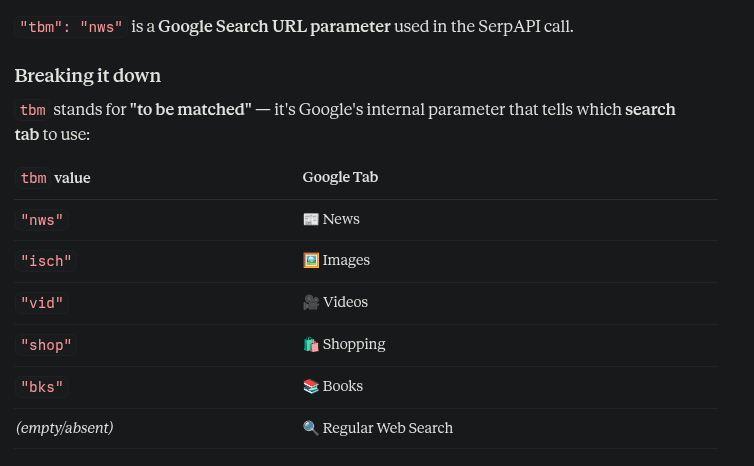

In [4]:
search = GoogleSearch({
    "q": "SolarGeo Engineering",
    "tbm": "nws",   # news tab
    "api_key": os.getenv("serp_api_key")
})

In [12]:
search.get_dict()["news_results"]

##issue: not much recent

[{'position': 1,
  'link': 'https://www.ucs.org/resources/what-solar-geoengineering',
  'title': 'What is Solar Geoengineering?',
  'source': 'Union of Concerned Scientists',
  'date': 'Oct 29, 2020',
  'published_at': '2020-10-29 07:00:00 UTC',
  'snippet': 'Solar geoengineering technologies cool the earth by reflecting sunlight back into space—but they pose many risks, challenges,...',
  'favicon': 'https://serpapi.com/searches/69bd3b5452acc67044e4a8c3/images/eK8DZF1-0iWaJAGdyQ0c8dImEGQ9crU3jcj0hVGi24w.png',
  'thumbnail': 'https://serpapi.com/searches/69bd3b5452acc67044e4a8c3/images/4bW7xJynVXQvajhwzOPEBC5U2PmnOkik5v3MS6QKjFo.jpeg'},
 {'position': 2,
  'link': 'https://www.theatlantic.com/science/archive/2018/01/what-happens-if-we-start-geo-engineeringand-then-suddenly-stop/551354/',
  'title': 'What Happens If We Start Solar Geo-Engineering—and Then Suddenly Stop?',
  'source': 'The Atlantic',
  'date': 'Jan 25, 2018',
  'published_at': '2018-01-25 08:00:00 UTC',
  'snippet': 'Volc

In [ ]:
[print((news_element["snippet"]), news_element["date"]) for news_element in search.get_dict()["news_results"]]

Solar geoengineering technologies cool the earth by reflecting sunlight back into space—but they pose many risks, challenges,... Oct 29, 2020
Volcanoes, nuclear war, and solar geo-engineering. With a research portfolio that includes all three, Alan Robock is used to thinking about... Jan 25, 2018
MEDIA BRIEF September 11, 2023. Geoengineering technologies – carbon dioxide removal (CDR) and solar geoengineering or solar radiation modification (SRM... Sep 11, 2023
A branch of speculative technology that promises to counteract and even reverse global warming by altering Earth's atmosphere. Jan 11, 2023
Solar geoengineering could halve global temperature increases without making climate change worse, research shows. Mar 11, 2019
Injecting pollutants into the atmosphere to reflect the sun would be extremely dangerous, but the UK is funding field trials. Mar 12, 2025
Manipulating climate via SRM can lead to extreme weather events including flood, drought, and windstorms, these triggering pro

[None, None, None, None, None, None, None, None, None, None]

# 3. Scraping (No API Key) with newspaper3k

In [7]:
from newspaper import Article
import requests
from bs4 import BeautifulSoup

In [8]:
# Find articles via Google RSS
rss_url = "https://news.google.com/rss/search?q=solar+geoengineering+india&hl=en"
soup = BeautifulSoup(requests.get(rss_url).content, "xml")

In [126]:
for item in soup.find_all("item")[:10]:
    source = item.find("source")
    source_name = source.text if source else "Unknown"
    source_url = source.get("url") if source else None

    print(f"Title  : {item.title.text}")
    print(f"Source : {source_name} ({source_url})")
    print(f"Link   : {item.link.text}")
    print()

Title  : Is Delhi Rain Fake? What is Solar Geoengineering as Viral Claims Link Sudden Weather Change to Bill Gates’ Experiments - The Sunday Guardian
Source : The Sunday Guardian (https://sundayguardianlive.com)
Link   : https://news.google.com/rss/articles/CBMi9wFBVV95cUxNeDlTelpYQ0xqeVdpbG9GMnNXY2tMQjRLa2pVWkI4Z0VvTHlpMFB5Zk9YRjFnUkpYQUg0cWpXb1ZBNlNZRTJBQXlCa3I2WEwyYmozbkh1Sk1kcTFCeFJrMUhkYTBnZnp6VUstSG81NjdhRXlsV3JaM09Mc2p5eXJwX1pQVkdTTFRfcXJPTkFTcWVEN1JJMTVodnlzdkU0a1NtMUJ4SzdSTnlsYUZ3TEZTdlc3RlJtREtuYW5KQ3hLcnpTOXdSbFBVT0tDcmI1UXgyV2RwVjFIdDBjdTZ5WGdxVFdVWWJVX1QwLWFyVjRlMDlWTEVGXzlz?oc=5

Title  : What Is Solar Geoengineering? Is Sudden Weather Shift Linked To Viral Claims About Bill Gates’ Climate Test - Oneindia
Source : Oneindia (https://www.oneindia.com)
Link   : https://news.google.com/rss/articles/CBMi2gFBVV95cUxQNUV5YlpuSG13eDlOaFpMYnZma056bWVqZms2anJoZjRaV2tQRWMxVHZpRmNTUlY4eVR6TGJrbXJzMEkyRF9aRFJGUTBJd05WeGt2RmktTmZDU0RNQTVoNEVTUkNFaFUxbzJ5NXlqQ0dQNW00clVUMFZ0RmlocnhiNVUw

### Multiple Functions for searching news for routing

In [12]:
import time

In [13]:
def gdelt_news_search(query: str, max_records: int = 10):

    params = {
        "query": query,
        "mode": "ArtList",          # correct mode for fetching articles
        "maxrecords": max_records,
        "format": "json",
        "timespan": "1month"        # elps get valid non-empty results
    }

    try:
        start_time = time.perf_counter()# track time taken for API call
        response = requests.get("https://api.gdeltproject.org/api/v2/doc/doc", params=params, timeout=10)

        print("Status Code :", response.status_code)
        print("Raw Response:", response.text[:300])
        
        # check if response is empty before parsing
        if not response.text.strip():
            print("GDELT returned empty response")
            return []
        
        end_time = time.perf_counter()
        data = response.json()

        # safely get articles key (may not always exist)
        print(f"GDELT API call took {end_time - start_time:.2f} seconds")
        articles = data.get("articles", [])

        if not articles:
            print("No articles found for query:", query)
            return []
        print(f"GDELT API call took {end_time - start_time:.2f} seconds") 
        return articles

    except Exception as e:
        print(f"Unexpected error: {e}")
        return []

In [14]:
article = gdelt_news_search('Solar Geoengineering')

Unexpected error: HTTPSConnectionPool(host='api.gdeltproject.org', port=443): Read timed out. (read timeout=10)


In [15]:
def serpapi_news_search(query: str, max_results: int = 10):

    try:
        print("INFO: Making SerpAPI call for query:", query)
        start_time = time.perf_counter() # track time taken for API call
        search = GoogleSearch({
            "q": query,
            "tbm": "nws",   # news tab
            "api_key": os.getenv("serp_api_key")
        })
        results = search.get_dict().get("news_results", [])
        end_time = time.perf_counter()

        if not results:
            print("SerpAPI returned no news results for query:", query)
            return []
        print(f"SerpAPI call took {end_time - start_time:.2f} seconds")

        return results[:max_results]
    except Exception as e:
        print(f"SerpAPI error: {e}")
        return []

In [16]:
article_serp = serpapi_news_search("Solar Geoengineering India")

INFO: Making SerpAPI call for query: Solar Geoengineering India
SerpAPI call took 1.13 seconds


In [26]:
print(article_serp[0]['snippet'])

What is solar geoengineering? Explore the viral claims linking Bill Gates to Delhi-NCR's sudden weather change and understand the real...


In [18]:
def scrapping_news_search(query:list, max_results: int = 10):

    try:
        # Find articles via Google RSS
        print("INFO: Scraping Google News RSS feed for query:", query)
        query = [char.lower() for char in query]
        separator = '+'
        query = separator.join(query)
        rss_url = f"https://news.google.com/rss/search?q={query}&hl=en"

        start_time = time.perf_counter()
        soup = BeautifulSoup(requests.get(rss_url).content, "xml")

        # check if we got any items back
        items = soup.find_all("item")
        if not items:
            print("No news items found in RSS feed for query:", query)
            return []
        
        
        else:
            articles = []

            for item in items[:max_results]:
                article = {}  

                source = item.find("source")  # extract source from each item

                #print(s)

                article["title"] = item.title.text
                article["source_name"] = source.text if source else "Unknown"
                article["source_url"] = source.get("url") if source else None
                article["link"] = item.link.text

                articles.append(article)

            end_time = time.perf_counter()
            print(f"Scraping call took {end_time - start_time:.2f} seconds")
            return articles

    except Exception as e:
        print(f"Error during scraping news search: {e}")
        return []

In [19]:
article_scrap = scrapping_news_search(["geo", "solarengineering", "India"])

INFO: Scraping Google News RSS feed for query: ['geo', 'solarengineering', 'India']
Scraping call took 0.89 seconds


In [20]:
article_scrap

[{'title': 'Indian scientists are showing an interest in advancing solar geoengineering research - Mongabay-India',
  'source_name': 'Mongabay-India',
  'source_url': 'https://india.mongabay.com',
  'link': 'https://news.google.com/rss/articles/CBMivAFBVV95cUxPUkJ3bmVSYWlnZmVGRm5EQkNMRm9HbGpFMWRBTklvem5iZnR2TkowbVFyTThrS0VyamptWHZpZmNOa0owOENDYXpfSTJ6TTF4a19HeElOTmRSbG4zbkhBZnljQnJIU3Z6SWZsSmlmc2hHbmlXQ0hCcU1yaEU5QTlIWlhwYzRKbHBfUmd0Znp4TFJlUV9qaHFiQjVOcExVSWU0T3h3eThhRGZUUTFrYXBsek55d3d6Yk1XOHNhVA?oc=5'},
 {'title': 'Solar Geoengineering: Why Bill Gates Wants It, But These Experts Want To Stop It - Forbes',
  'source_name': 'Forbes',
  'source_url': 'https://www.forbes.com',
  'link': 'https://news.google.com/rss/articles/CBMizAFBVV95cUxPVjZxZ3c5dVd1TVBERXpPMElMRGp5aFRjMDl1VFVZVzhINzJGT2JGUmd0VUpDcnNIZzFxYlR2WnNtWlcyS1g5MFdsMnhyZjk4bk5iODR3SDRnSGg1a3BQUjRianJGNmdhUFg5Umd1M210ZkJwMV93MkJ2Uzc1UEZGcmFkSDZRT2FrNGtLRV9YUFl1aEgzcEVFWnZCZ3ZfbzByNDQySUhHYjhVaFZ0TEpXR25GMVR4eVNBTWRNYndva3FmZ3N

In [21]:
def get_articles_router(keywords: list, max_results: int = 10, search_method: str = 'serp'):

    keywords = [keyword.lower() for keyword in keywords]
    query = ' '.join(keywords)

    if search_method == 'serp':
        print("INFO: Using SerpAPI")
        results = serpapi_news_search(query, max_results)

        if not results:
            print("INFO: SerpAPI returned no results, falling back to scraping")
            return scrapping_news_search(keywords, max_results)

        return results

    elif search_method == 'scrape':
        print("INFO: Using scraping")
        return scrapping_news_search(keywords, max_results)

    else:
        print(f"INFO: Unknown search_method '{search_method}', defaulting to serp API.")
        return serpapi_news_search(query, max_results)

In [22]:
articles = get_articles_router(["geo", "solarengineering", "India"], max_results=5)

INFO: Using SerpAPI
INFO: Making SerpAPI call for query: geo solarengineering india
SerpAPI call took 2.70 seconds


### Matching with Text Summaries or posts

In [23]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

/home/sjasmeet/miniconda3/envs/factcheckenv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [24]:
model = SentenceTransformer('all-MiniLM-L6-v2')

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 3969.11it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [ ]:
def get_article_text(article):
        if article["snippet"]: 
        # combine title + snippet for richer matching
                title   = article.get("title", "")
                snippet = article.get("snippet", "")
                return f"{title}. {snippet} ".strip()
        else:
                title = article.get("title", "")
                return f"{title}".strip()

In [33]:
text = get_article_text(articles[0])

In [34]:
text

"Bill Gates and the Solar Geoengineering Debate Explained. Explore the truth behind claims of Bill Gates 'dimming the sun.' Learn about solar geoengineering and its implications. Read more now!"

In [29]:
def semantic_search(query: str, articles: list, top_n: int = 3, threshold: float = 0.3):
    """
    Rank articles by semantic similarity to a query.
    
    args:
        query    : your search text (keyword, summary, claim, paragraph)
        articles : list of dicts with at least a 'snippet' or 'title' key
        top_n    : how many top results to return
        threshold: minimum similarity score to include (0 to 1)
    """

    if not articles:
        print("No articles to search through")
        return []

    # Extract text from each article 
    article_texts = [get_article_text(a) for a in articles]
    # Encode query and articles into vectors 
    query_vector   = model.encode([query])                    # shape: (1, 384)
    article_vectors = model.encode(article_texts)             # shape: (N, 384)

    # Compute cosine similarity 
    scores = cosine_similarity(query_vector, article_vectors)[0]  # shape: (N,)

    # Step D: Attach scores and rank 
    for i, article in enumerate(articles):
        article["similarity_score"] = round(float(scores[i]), 4)

    ranked = sorted(articles, key=lambda x: x["similarity_score"], reverse=True)

    # Step E: Filter by threshold and return top N 
    filtered = [a for a in ranked if a["similarity_score"] >= threshold]

    return filtered[:top_n]

### Key Topics Approach

In [35]:
keytopics = ['Bill Gates projects', 'contrails and temperature', 'climate engineering']

In [36]:
output_articles = {}

for keytopic in keytopics:
    #convert each keytopic to a list
    keywords = keytopic.split()
    print(f"\n\n=== Results for keytopic: '{keytopic}' ===")
    articles = get_articles_router(keywords, max_results=10, search_method='serp')
    if not articles:
        print("No articles found for this keytopic.")
        continue
    ranked = semantic_search(keytopic, articles, top_n=3, threshold=0.2)
    output_articles[keytopic] = ranked



=== Results for keytopic: 'Bill Gates projects' ===
INFO: Using SerpAPI
INFO: Making SerpAPI call for query: bill gates projects
SerpAPI call took 4.02 seconds


=== Results for keytopic: 'contrails and temperature' ===
INFO: Using SerpAPI
INFO: Making SerpAPI call for query: contrails and temperature
SerpAPI call took 2.00 seconds


=== Results for keytopic: 'climate engineering' ===
INFO: Using SerpAPI
INFO: Making SerpAPI call for query: climate engineering
SerpAPI call took 1.68 seconds


In [37]:
output_articles

{'Bill Gates projects': [{'position': 9,
   'link': 'https://www.britannica.com/money/Bill-Gates',
   'title': 'Bill Gates | Microsoft Cofounder, Philanthropist, & Author',
   'source': 'Britannica',
   'date': '1 week ago',
   'published_at': '2026-03-10 07:00:00 UTC',
   'snippet': 'Bill Gates (born October 28, 1955, Seattle, Washington) is an American computer programmer and entrepreneur...',
   'favicon': 'https://serpapi.com/searches/69be91368c60ca01e3cef9e8/images/RCaNADkFhwJ746zab4uZF4ROprCgDiv2uFddqjoX08o.png',
   'thumbnail': 'https://serpapi.com/searches/69be91368c60ca01e3cef9e8/images/01FuOZtnFFlOr946hHguwd0pVzkQWFVo6ckCOHYlvNo.jpeg',
   'similarity_score': 0.6256},
  {'position': 8,
   'link': 'https://www.hydrogeninsight.com/production/funding-still-committed-from-bill-gates-backed-fund-for-hydrogen-projects-despite-freeze-on-new-investments/2-1-1958924',
   'title': 'Funding ‘still committed’ from Bill Gates-backed fund for hydrogen projects despite freeze on new investme